In [3]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 23.3.1 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [4]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")


✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


Reading file: dataset/Histopathology_Datasets_Summary.xlsx
Successfully read as Excel file.
Saved: organ_distribution_hierarchy.pdf


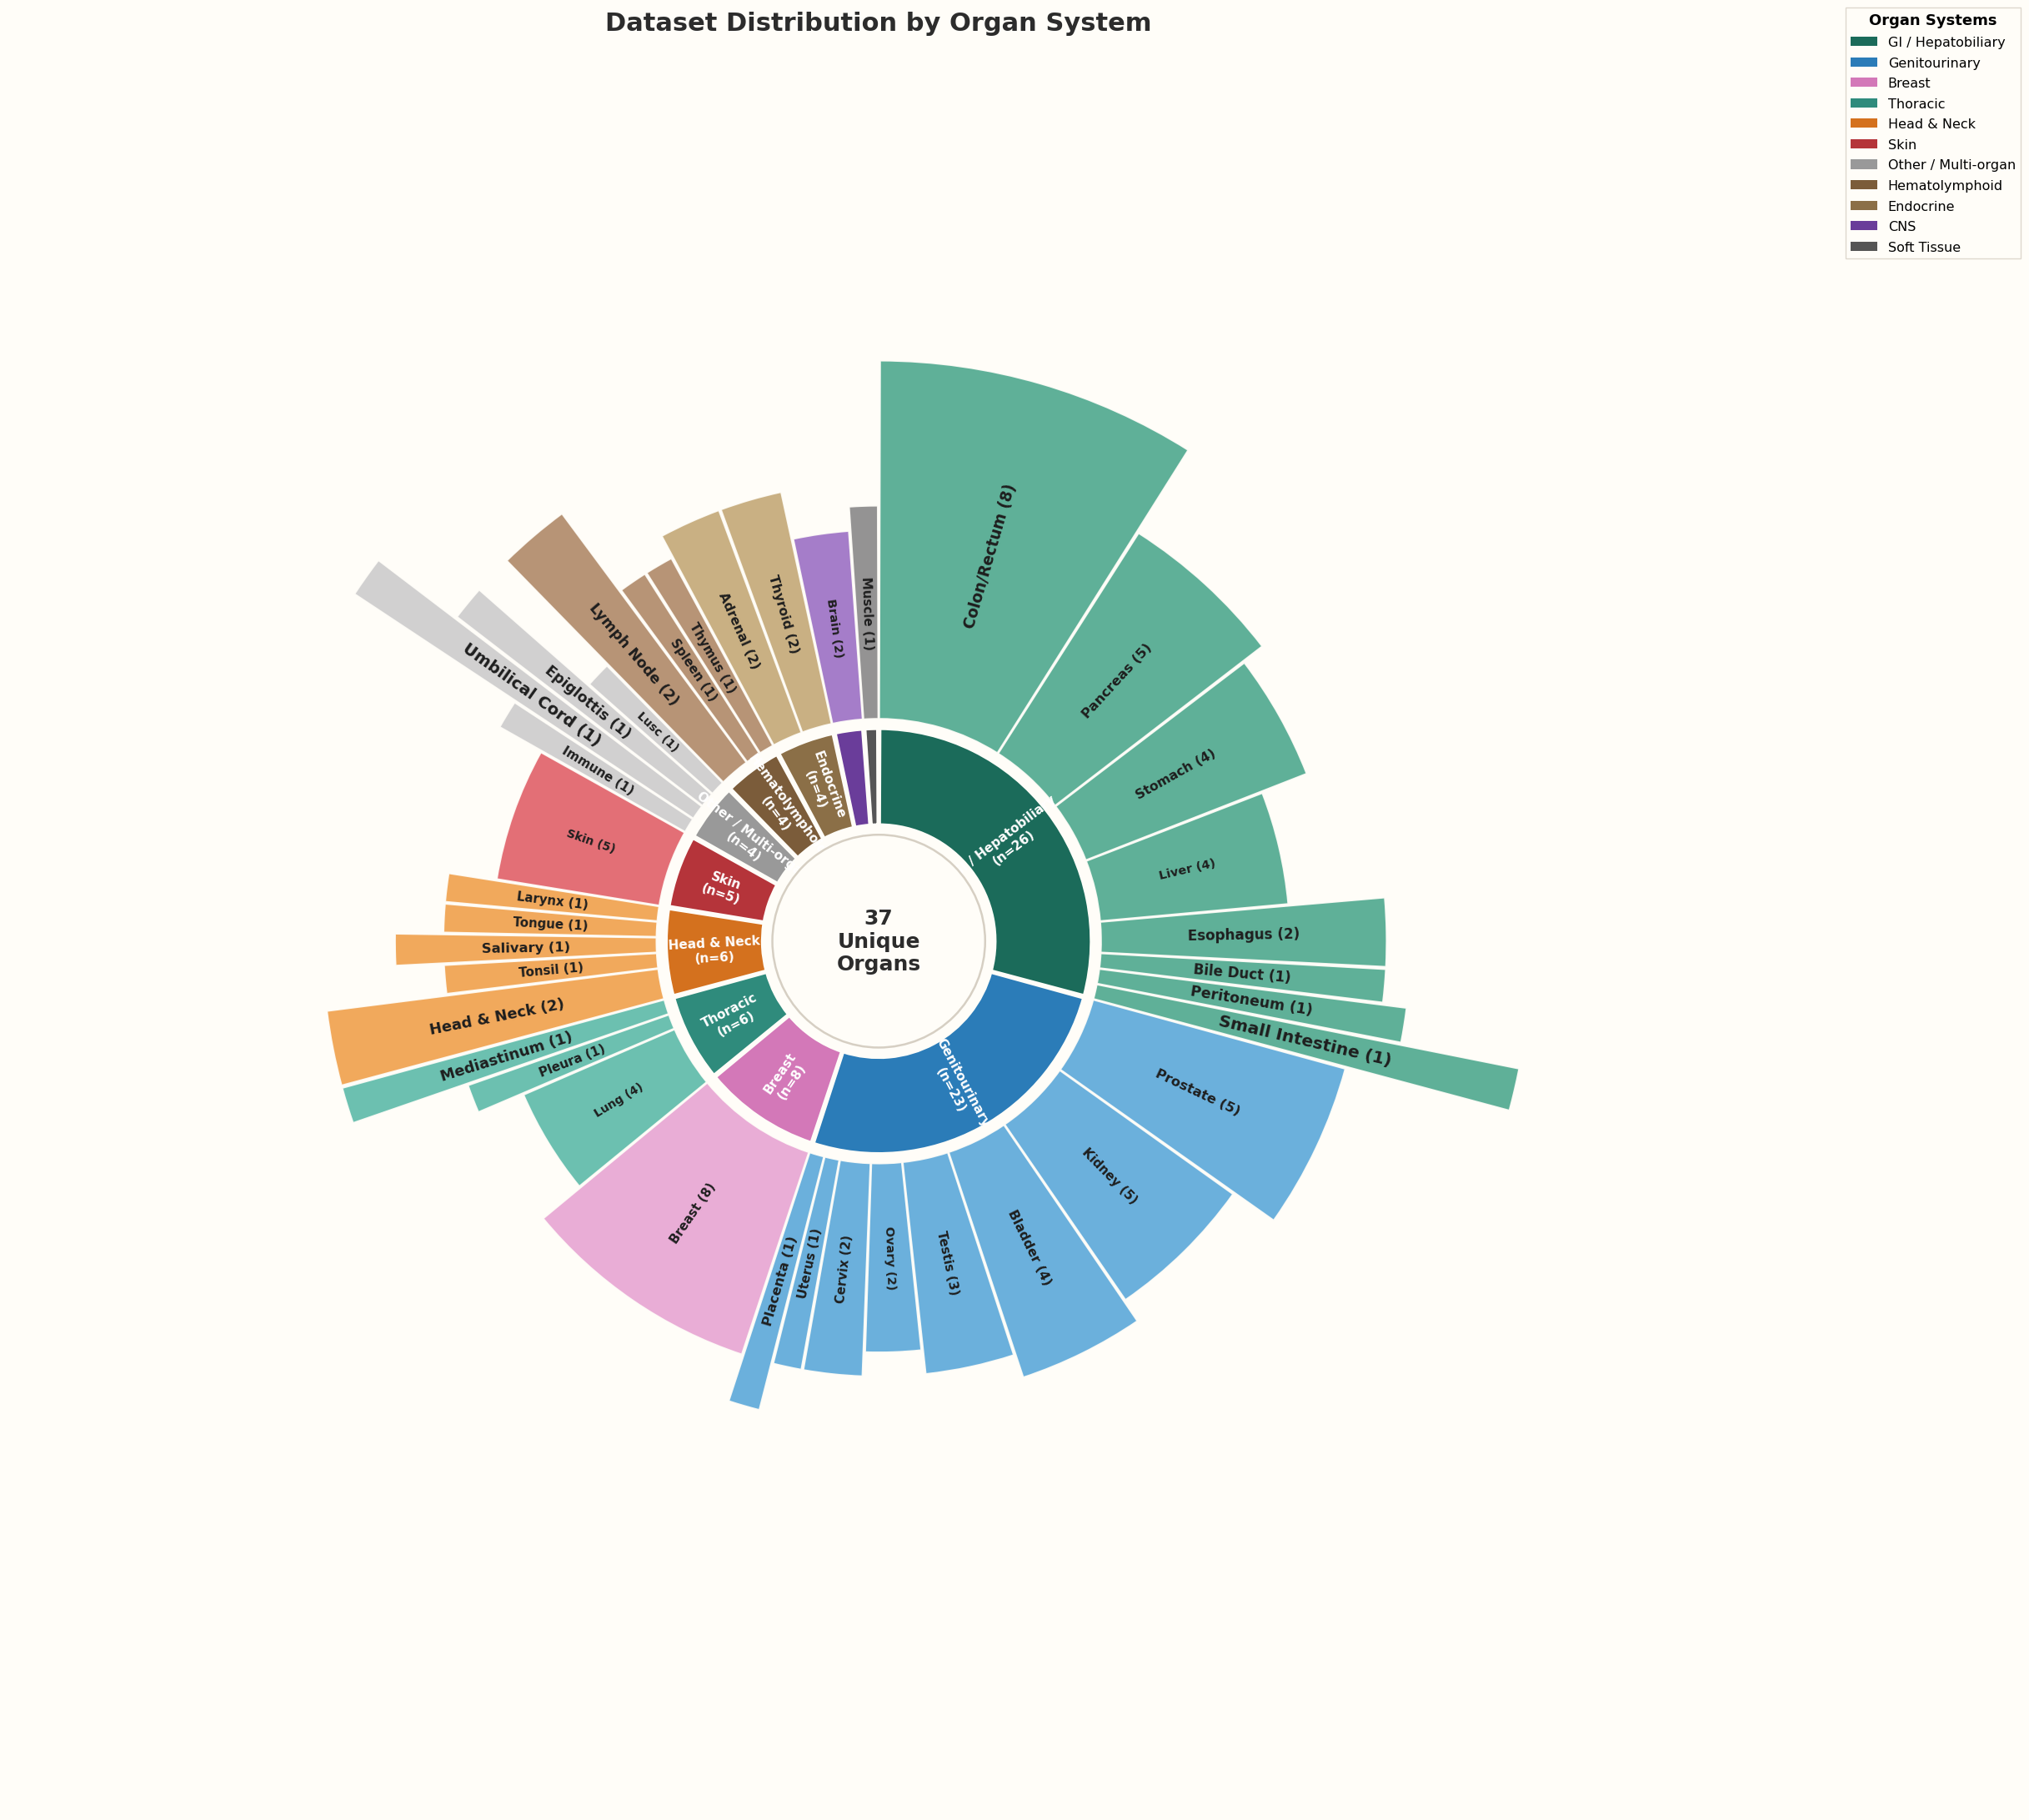

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from matplotlib.patches import Wedge, Patch
from collections import defaultdict, Counter
import os

# ==========================================
# 1. DATA LOADING (Robust to .xlsx vs .csv)
# ==========================================
# Update this path to where your file is located
file_path = "dataset/Histopathology_Datasets_Summary.xlsx" 

print(f"Reading file: {file_path}")

# Smart loader: Checks extension to use correct pandas function
if file_path.endswith('.xlsx'):
    try:
        df = pd.read_excel(file_path)
        print("Successfully read as Excel file.")
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        # Fallback: maybe it's a CSV named .xlsx?
        try:
            df = pd.read_csv(file_path, encoding='ISO-8859-1')
            print("Fallback: Read as CSV with ISO-8859-1 encoding.")
        except:
            raise e
else:
    # Default CSV reading with encoding fallback
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 failed, trying ISO-8859-1...")
        df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Ensure column exists (handle case sensitivity)
cols = {c.lower(): c for c in df.columns}
organ_col = cols.get('tissue/organ', 'Tissue/Organ') # specific to your dataset

# ==========================================
# 2. DATA CLEANING & MAPPING
# ==========================================
organ_alias_map = {
    'colorectal': 'Colon/Rectum', 'colon': 'Colon/Rectum', 'rectum': 'Colon/Rectum',
    'stomach': 'Stomach', 'oesophagus': 'Esophagus', 'esophagus': 'Esophagus',
    'jejunum': 'Small Intestine', 'bile duct': 'Bile Duct', 'liver': 'Liver',
    'pancreas': 'Pancreas', 'gallbladder': 'Gallbladder', 'peritoneum': 'Peritoneum',
    'kidney': 'Kidney', 'bladder': 'Bladder', 'urinary bladder': 'Bladder',
    'prostate': 'Prostate', 'testis': 'Testis', 'ovarian': 'Ovary', 'ovary': 'Ovary',
    'cervix': 'Cervix', 'cervical': 'Cervix', 'uterus': 'Uterus', 'placenta': 'Placenta',
    'breast': 'Breast',
    'lung': 'Lung', 'pleura': 'Pleura', 'mediastinum': 'Mediastinum',
    'skin': 'Skin', 'melanoma': 'Skin',
    'brain': 'Brain', 'gbm': 'Brain', 'lgg': 'Brain', 'cerebellum': 'Brain', 'cerebrum': 'Brain',
    'head&neck': 'Head & Neck', 'head & neck': 'Head & Neck', 'hnscc': 'Head & Neck',
    'larynx': 'Larynx', 'tongue': 'Tongue', 'tonsil': 'Tonsil', 'salivary gland': 'Salivary',
    'thyroid': 'Thyroid', 'adrenal': 'Adrenal',
    'lymph': 'Lymph Node', 'lymph node': 'Lymph Node', 'thymus': 'Thymus', 'spleen': 'Spleen',
    'muscle': 'Muscle'
}

system_map = {
    'Colon/Rectum': 'GI / Hepatobiliary', 'Stomach': 'GI / Hepatobiliary', 
    'Esophagus': 'GI / Hepatobiliary', 'Small Intestine': 'GI / Hepatobiliary',
    'Bile Duct': 'GI / Hepatobiliary', 'Liver': 'GI / Hepatobiliary', 
    'Pancreas': 'GI / Hepatobiliary', 'Gallbladder': 'GI / Hepatobiliary', 
    'Peritoneum': 'GI / Hepatobiliary',
    'Kidney': 'Genitourinary', 'Bladder': 'Genitourinary', 'Prostate': 'Genitourinary',
    'Testis': 'Genitourinary', 'Ovary': 'Genitourinary', 'Cervix': 'Genitourinary', 
    'Uterus': 'Genitourinary', 'Placenta': 'Genitourinary',
    'Breast': 'Breast',
    'Lung': 'Thoracic', 'Pleura': 'Thoracic', 'Mediastinum': 'Thoracic',
    'Skin': 'Skin',
    'Brain': 'CNS',
    'Head & Neck': 'Head & Neck', 'Larynx': 'Head & Neck', 'Tongue': 'Head & Neck', 
    'Tonsil': 'Head & Neck', 'Salivary': 'Head & Neck',
    'Thyroid': 'Endocrine', 'Adrenal': 'Endocrine',
    'Lymph Node': 'Hematolymphoid', 'Thymus': 'Hematolymphoid', 'Spleen': 'Hematolymphoid',
    'Muscle': 'Soft Tissue'
}

def parse_organs(text):
    if not isinstance(text, str) or text in ['Yes', 'No', 'Partial', 'nan', 'Orion CRC']:
        return []
    
    text_clean = text.strip()
    extracted_items = []

    if 'Human organs:' in text_clean:
        part = text_clean.split('Mouse organs:')[0].replace('Human organs:', '')
        part = re.sub(r'\([^)]*\)', '', part)
        items = re.split(r',| and ', part)
        extracted_items = items
    elif any(x in text_clean for x in ['organs (', 'tissues (', 'cancer types (']):
        match = re.search(r'\((.*?)\)', text_clean)
        if match:
            extracted_items = match.group(1).split(',')
    else:
        base = re.sub(r'\s*\(.*?\)', '', text_clean)
        extracted_items = [base]

    final_organs = []
    for item in extracted_items:
        item = item.strip().lower()
        if not item: continue
        
        found = False
        for key, val in organ_alias_map.items():
            if key == item:
                final_organs.append(val)
                found = True
                break
        if not found:
            for key, val in organ_alias_map.items():
                if key in item:
                    final_organs.append(val)
                    found = True
                    break
        
        if not found and len(item) > 2:
            final_organs.append(item.title())
            
    return list(set(final_organs))

cat_types = defaultdict(Counter)
for entry in df[organ_col]:
    organs = parse_organs(entry)
    for organ in organs:
        category = system_map.get(organ, 'Other / Multi-organ')
        cat_types[category][organ] += 1

if 'Other / Multi-organ' in cat_types and not cat_types['Other / Multi-organ']:
    del cat_types['Other / Multi-organ']

sorted_cats = sorted(cat_types.items(), key=lambda x: -sum(x[1].values()))
total_cases = sum(sum(v.values()) for v in cat_types.values())

# ==========================================
# 3. STYLE & PLOTTING
# ==========================================
colors_inner = {
    'GI / Hepatobiliary': '#1B6B5A', 'Genitourinary': '#2B7CB8', 'Breast': '#D378B8',
    'Thoracic': '#2F8B7C', 'Skin': '#B5343A', 'CNS': '#6A3D9A',
    'Head & Neck': '#D4711E', 'Endocrine': '#8B6F47', 'Hematolymphoid': '#7B5C3A',
    'Soft Tissue': '#555555', 'Other / Multi-organ':'#999999'
}
colors_outer = {
    'GI / Hepatobiliary': '#4DA88E', 'Genitourinary': '#5BA8D9', 'Breast': '#E7A4D3',
    'Thoracic': '#5CBAA8', 'Skin': '#E06068', 'CNS': '#9B6FC4',
    'Head & Neck': '#F0A04B', 'Endocrine': '#C4A876', 'Hematolymphoid': '#B08968',
    'Soft Tissue': '#888888', 'Other / Multi-organ':'#CCCCCC'
}

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(24, 24))
fig.patch.set_facecolor('#FFFDF8')
ax.set_facecolor('#FFFDF8')
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.axis('off')

inner_r1, inner_r2 = 0.6, 1.1
outer_r1 = 1.15

all_outer_labels = [name for _, tc in sorted_cats for name in tc]
min_len = min(len(l) for l in all_outer_labels) if all_outer_labels else 0
max_len = max(len(l) for l in all_outer_labels) if all_outer_labels else 10

def get_outer_radius(label):
    norm = (len(label) - min_len) / (max_len - min_len + 1)
    return 2.0 + norm * 1.5

def get_font_size(label):
    norm = (get_outer_radius(label) - 2.0) / 1.5
    return 10 + norm * 5

cat_gap, type_gap, current_angle = 0.5, 0.3, 90

for cat, type_counter in sorted_cats:
    cat_total = sum(type_counter.values())
    color_in, color_out = colors_inner.get(cat, '#888'), colors_outer.get(cat, '#AAA')
    
    cat_angle_span = (cat_total / total_cases) * 360
    cat_start, cat_end = current_angle, current_angle - cat_angle_span
    
    # Inner Wedge
    wi_start, wi_end = cat_start - cat_gap / 2, cat_end + cat_gap / 2
    if wi_start > wi_end:
        ax.add_patch(Wedge((0, 0), inner_r2, wi_end, wi_start, width=(inner_r2 - inner_r1),
                           facecolor=color_in, edgecolor='#FFFDF8', linewidth=3.0))
        if (wi_start - wi_end) > 8:
            label_r, mid_ang_deg = (inner_r1 + inner_r2) / 2, (wi_start + wi_end) / 2
            flip = (90 < mid_ang_deg % 360 < 270)
            rotation = mid_ang_deg + (180 if flip else 0)
            ax.text(label_r * np.cos(np.deg2rad(mid_ang_deg)), label_r * np.sin(np.deg2rad(mid_ang_deg)), 
                    f"{cat}\n(n={cat_total})", ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white', rotation=rotation, rotation_mode='anchor')

    # Outer Wedges
    cur = cat_start
    for type_name, type_count in type_counter.most_common():
        span = (type_count / total_cases) * 360
        wo_start, wo_end = cur - type_gap / 2, (cur - span) + type_gap / 2
        r2 = get_outer_radius(type_name)
        
        if wo_start > wo_end:
            ax.add_patch(Wedge((0, 0), r2, wo_end, wo_start, width=(r2 - outer_r1),
                               facecolor=color_out, edgecolor='#FFFDF8', linewidth=1.2, alpha=0.9))
            
            mid_ang = (wo_start + wo_end) / 2
            mid_ang_rad = np.deg2rad(mid_ang)
            label_r = (outer_r1 + r2) / 2
            x, y = label_r * np.cos(mid_ang_rad), label_r * np.sin(mid_ang_rad)
            rotation = mid_ang + (180 if 90 < mid_ang % 360 < 270 else 0)
            
            ax.text(x, y, f"{type_name} ({type_count})", ha='center', va='center', fontsize=get_font_size(type_name),
                    fontweight='bold', color='#1E1E1E', rotation=rotation, rotation_mode='anchor')
        cur -= span
    current_angle -= cat_angle_span

# ==========================================
# 4. FINAL TOUCHES
# ==========================================
ax.add_patch(plt.Circle((0, 0), 0.55, facecolor='#FFFDF8', edgecolor='#D6CFC3', linewidth=1.8, zorder=5))
ax.text(0, 0, f"{len(all_outer_labels)}\nUnique\nOrgans", ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2C2C2C', zorder=6)

legend_elements = [Patch(facecolor=colors_inner.get(cat, '#888'), edgecolor='none', label=cat) for cat, _ in sorted_cats]
leg = ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.16, 1.04),
                frameon=True, fancybox=False, edgecolor='#D6CFC3', facecolor='#FFFDF8', fontsize=11.5,
                title='Organ Systems', title_fontsize=13, labelspacing=0.6)
leg.get_title().set_fontweight('bold')

plt.title("Dataset Distribution by Organ System", fontsize=22, fontweight='bold', pad=35, color='#2C2C2C')
plt.tight_layout()
print("Saved: organ_distribution_hierarchy.pdf")
plt.show()

✓ PDF saved successfully to: figures/radial_chart.pdf
✓ This PDF is fully editable in Adobe Illustrator


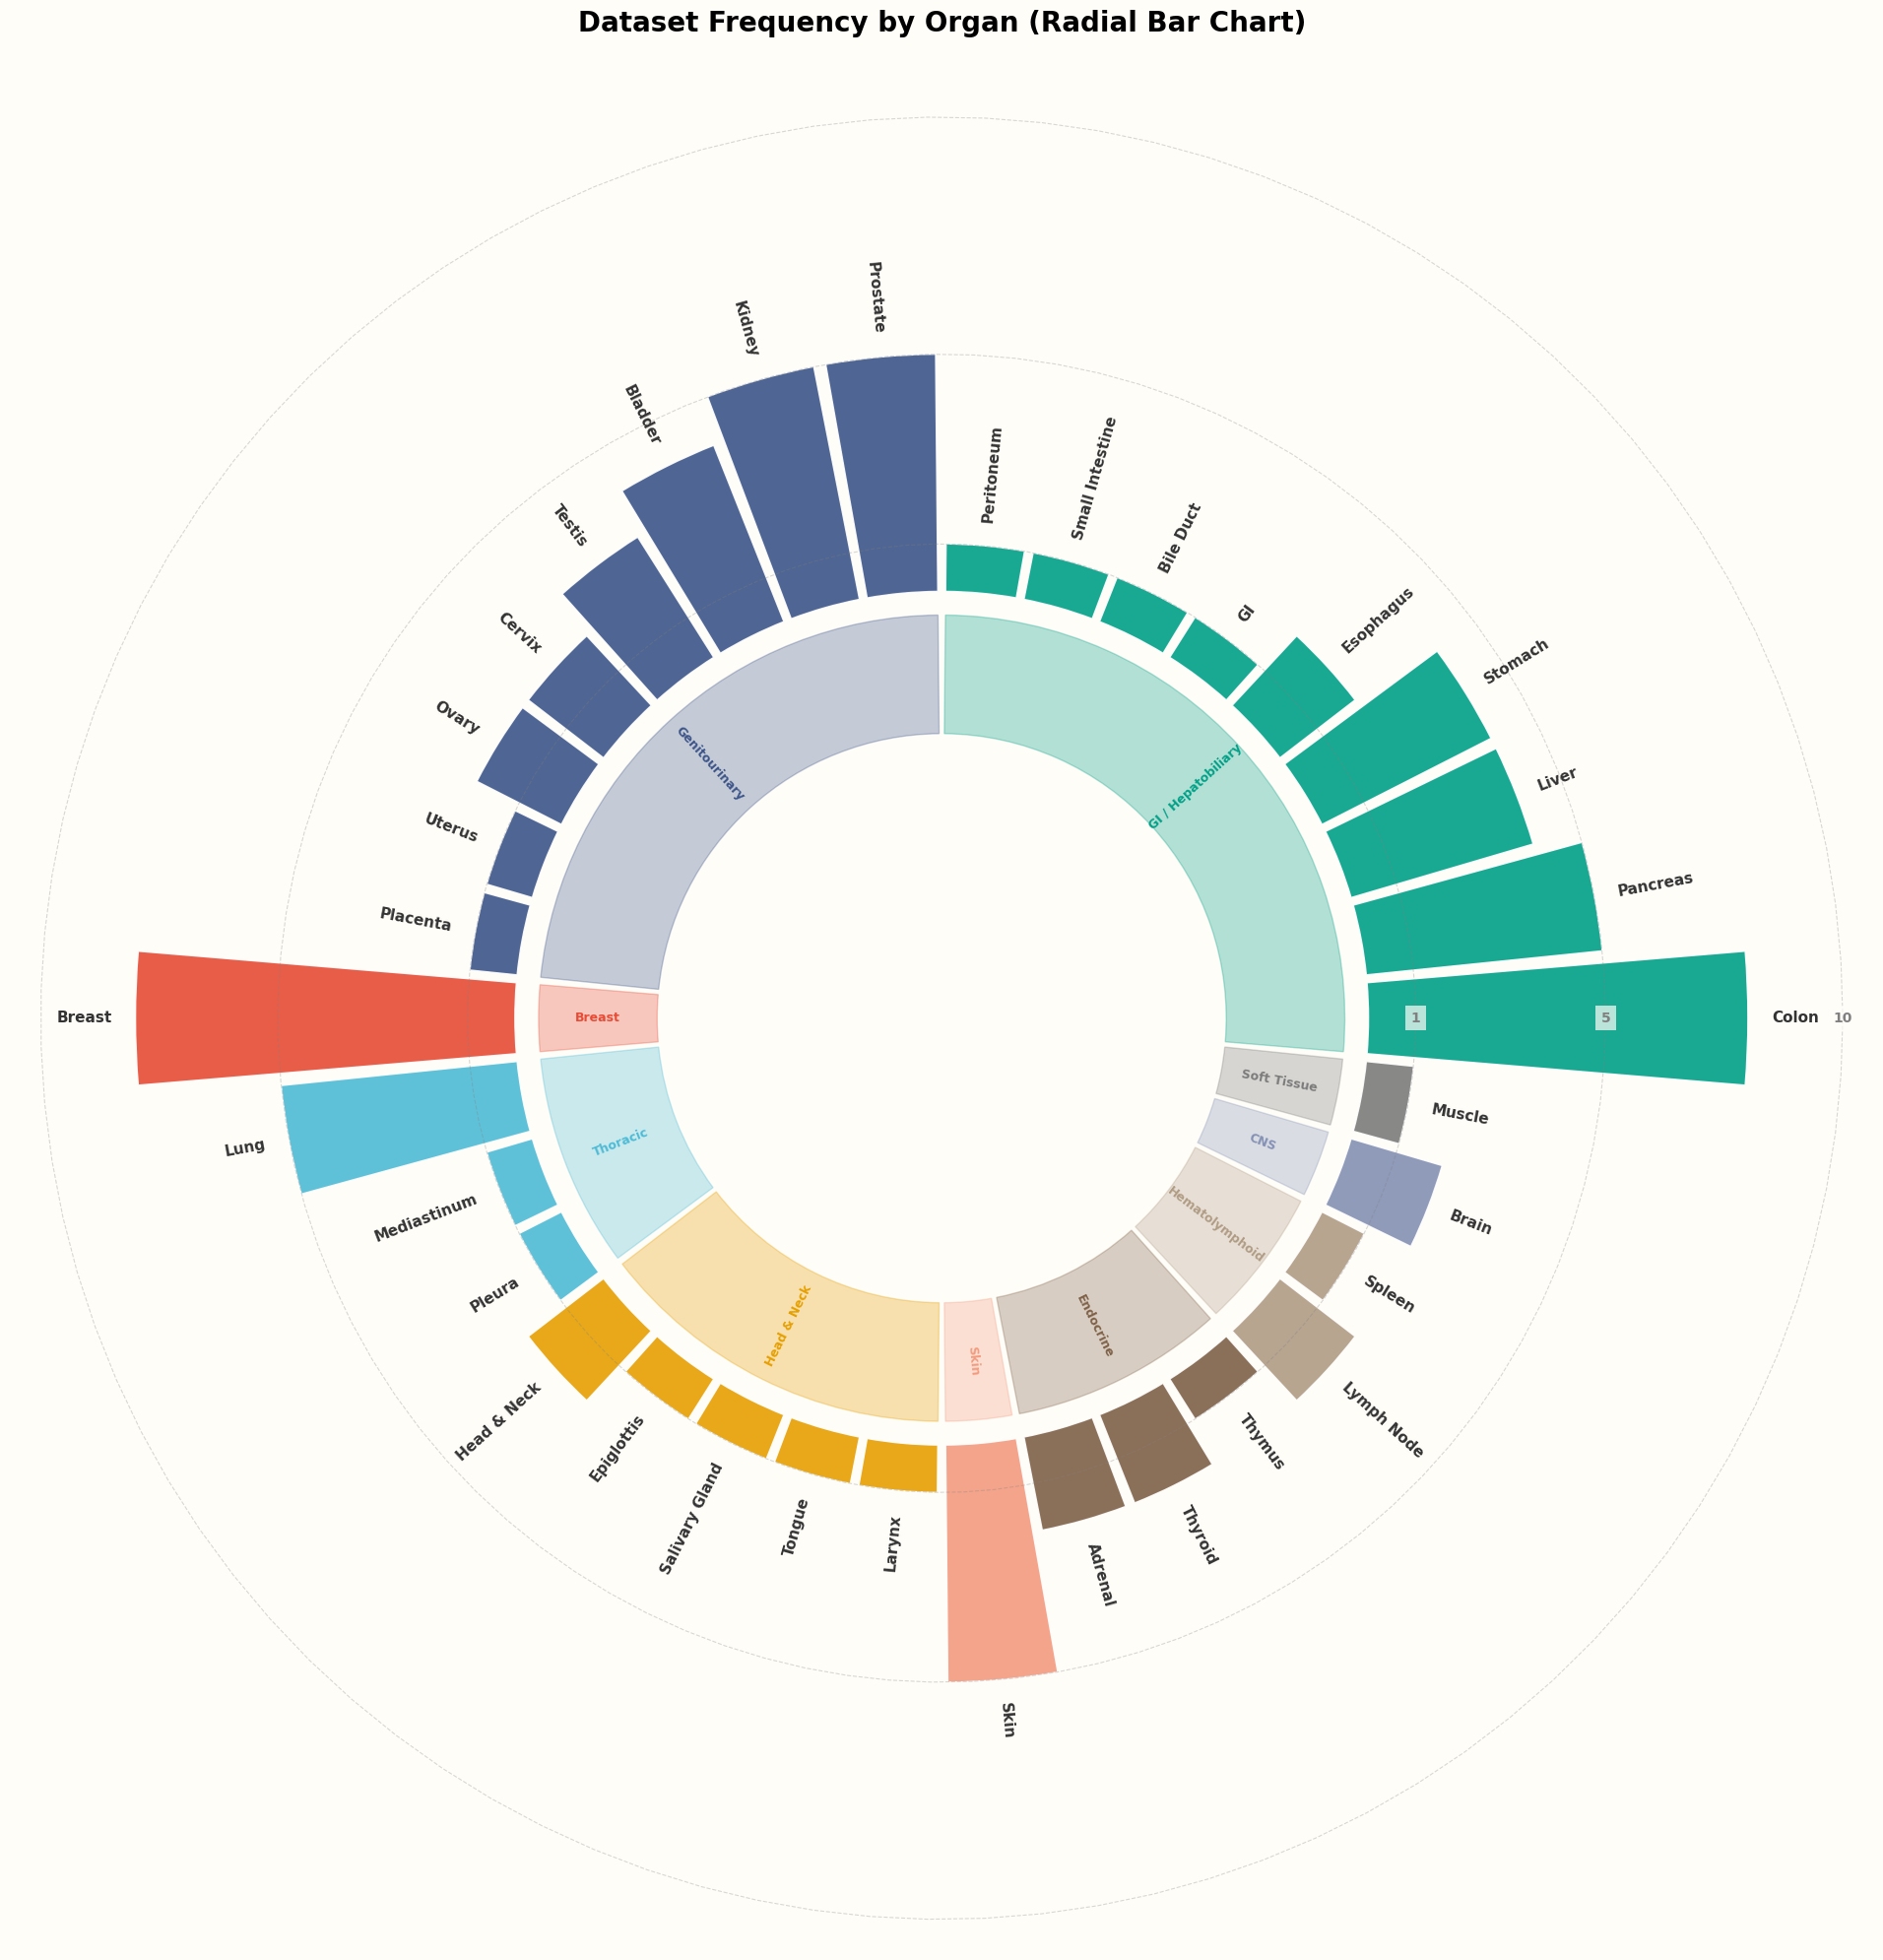

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter
import os

# ==========================================
# 1. DATA PREPARATION
# ==========================================
datasets_organs = {
    'TissueNet': ['Breast', 'GI', 'Lung', 'Pancreas', 'Skin'],
    'Orion CRC': ['Colon'],
    'Xenium': ['Breast', 'Cervix', 'Lung', 'Lymph Node', 'Ovary', 'Pancreas', 'Prostate', 'Skin'],
    'Lizard': ['Colon'],
    'PanNuke': ['Adrenal', 'Bile Duct', 'Bladder', 'Breast', 'Cervix', 'Colon', 'Esophagus', 'Head & Neck', 'Kidney', 'Liver', 'Lung', 'Ovary', 'Pancreas', 'Prostate', 'Skin', 'Stomach', 'Testis', 'Thyroid', 'Uterus'],
    'MoNuSAC': ['Breast', 'Kidney', 'Prostate', 'Colon'],
    'BC': ['Breast'],
    'Kumar': ['Breast', 'Kidney', 'Liver', 'Prostate', 'Bladder', 'Colon', 'Stomach'],
    'NuInsSeg': ['Brain', 'Colon', 'Epiglottis', 'Small Intestine', 'Kidney', 'Liver', 'Lung', 'Skin', 'Muscle', 'Esophagus', 'Pancreas', 'Peritoneum', 'Placenta', 'Salivary Gland', 'Spleen', 'Stomach', 'Testis', 'Tongue', 'Bladder'],
    'MoNuSeg': ['Breast', 'Kidney', 'Liver', 'Prostate', 'Bladder', 'Colon', 'Stomach'],
    'CoNSeP': ['Colon'],
    'CPM-17': ['Brain', 'Head & Neck', 'Lung'],
    'CryoNuSeg': ['Adrenal', 'Larynx', 'Lymph Node', 'Mediastinum', 'Pancreas', 'Pleura', 'Skin', 'Testis', 'Thymus', 'Thyroid'],
    'TNBC': ['Breast']
}

system_map = {
    'Colon': 'GI / Hepatobiliary', 'Stomach': 'GI / Hepatobiliary', 
    'Esophagus': 'GI / Hepatobiliary', 'Small Intestine': 'GI / Hepatobiliary', 'GI': 'GI / Hepatobiliary',
    'Bile Duct': 'GI / Hepatobiliary', 'Liver': 'GI / Hepatobiliary', 
    'Pancreas': 'GI / Hepatobiliary', 'Peritoneum': 'GI / Hepatobiliary',
    'Kidney': 'Genitourinary', 'Bladder': 'Genitourinary', 'Prostate': 'Genitourinary',
    'Testis': 'Genitourinary', 'Ovary': 'Genitourinary', 'Cervix': 'Genitourinary', 
    'Uterus': 'Genitourinary', 'Placenta': 'Genitourinary',
    'Breast': 'Breast',
    'Lung': 'Thoracic', 'Pleura': 'Thoracic', 'Mediastinum': 'Thoracic',
    'Skin': 'Skin',
    'Brain': 'CNS',
    'Head & Neck': 'Head & Neck', 'Larynx': 'Head & Neck', 'Tongue': 'Head & Neck', 
    'Epiglottis': 'Head & Neck', 'Salivary Gland': 'Head & Neck',
    'Thyroid': 'Endocrine', 'Adrenal': 'Endocrine', 'Thymus': 'Endocrine',
    'Lymph Node': 'Hematolymphoid', 'Spleen': 'Hematolymphoid',
    'Muscle': 'Soft Tissue'
}

# 1. Flatten Data to count occurrences per Organ
organ_counts = Counter()
for organs in datasets_organs.values():
    organ_counts.update(organs)

# 2. Group Data by System for Plotting
grouped_data = defaultdict(list)
for organ, count in organ_counts.items():
    sys = system_map.get(organ, 'Other')
    grouped_data[sys].append((organ, count))

# 3. Sort Systems by total count, and Organs within systems by count
sorted_systems = sorted(grouped_data.items(), key=lambda x: sum(i[1] for i in x[1]), reverse=True)

# Flatten back into a plotting list
labels = []
counts = []
colors = []
system_boundaries = [] # To draw the inner system arcs

# Define Colors
system_colors = {
    'GI / Hepatobiliary': '#00A087', # NPG Teal
    'Genitourinary': '#3C5488',      # NPG Dark Blue
    'Breast': '#E64B35',             # NPG Red/Salmon
    'Thoracic': '#4DBBD5',           # NPG Light Blue
    'Skin': '#F39B7F',               # NPG Peach
    'CNS': '#8491B4',                # NPG Muted Purple/Grey
    'Head & Neck': '#3C5488',        # Elegant Orange
    'Endocrine': '#7E6148',          # NPG Brown
    'Hematolymphoid': '#B09C85',     # NPG Beige/Grey
    'Soft Tissue': '#7B7B7B'         # Neutral Grey
}

current_idx = 0
for sys_name, items in sorted_systems:
    # Sort organs inside the system (optional: descending count)
    items.sort(key=lambda x: x[1], reverse=True)
    
    start_idx = current_idx
    for organ, count in items:
        labels.append(f"{organ}")
        counts.append(count)
        colors.append(system_colors.get(sys_name, '#999'))
        current_idx += 1
    
    system_boundaries.append((start_idx, current_idx, sys_name, system_colors.get(sys_name, '#999')))

# ==========================================
# 2. PLOTTING
# ==========================================
# Configure matplotlib for proper text rendering in PDF (not converting to paths)
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts - selectable in Illustrator
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'sans-serif'

N = len(labels)
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
width = (2 * np.pi) / N * 0.9  # 0.9 leaves a small gap between bars

# --- CHANGE 1: INCREASED BOTTOM RADIUS ---
# Changed from 4 to 12 to make the center 3x larger
bottom = 9  

# Set up matplotlib to use PDF backend for better vector output
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#FFFDF8')
fig.patch.set_facecolor('#FFFDF8')

# 1. Draw the Bars (Organs)
bars = ax.bar(theta, counts, width=width, bottom=bottom, color=colors, alpha=0.9, edgecolor='white', linewidth=1)

# 2. Add Reference Circles (Gridlines)
yticks = [1, 5, 10]
for y in yticks:
    ax.plot(np.linspace(0, 2*np.pi, 100), [y+bottom]*100, color='gray', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.text(0, y+bottom, f"{y}", color='gray', fontsize=10, fontweight='bold', ha='center', va='center',  bbox=dict(facecolor='#FFFDF8', edgecolor='none', alpha=0.7))

# 3. Add Labels to Bars
for angle, bar, label, count in zip(theta, bars, labels, counts):
    rotation = np.rad2deg(angle)
    alignment = "left"
    
    if 90 < rotation < 270:
        rotation += 180
        alignment = "right"
    
    ax.text(angle, bottom + bar.get_height() + 0.5, label, 
            rotation=rotation, ha=alignment, va='center', rotation_mode='anchor',
            fontsize=11, fontweight='bold', color='#333')

# 4. Draw Inner System Rings (The "Category" labels)
for start, end, name, color in system_boundaries:
    start_angle = theta[start] - width/2
    end_angle = theta[end-1] + width/2
    
    mid_angle = (start_angle + end_angle) / 2
    if start_angle > end_angle: # Handle wrap-around
        mid_angle += np.pi
    
    # --- CHANGE 2: FLOATING INNER RING ---
    # Instead of filling the center, we make the ring occupy a band 
    # from radius 9 to 11.5. This leaves 0 to 9 empty.
    ring_height = 2.5
    ring_gap = 0.5 # Gap between ring and main bars
    ring_bottom = bottom - ring_height - ring_gap # 12 - 2.5 - 0.5 = 9
    
    ax.bar(mid_angle, ring_height, width=(end_angle - start_angle), bottom=ring_bottom, 
           color=color, alpha=0.3, edgecolor=color)
    
    # --- CHANGE 3: LABEL POSITION ---
    # Center the label inside the new ring band
    label_radius = ring_bottom + (ring_height / 2)
    
    sys_rot = np.rad2deg(mid_angle)
    if 90 < sys_rot < 270:
        sys_rot += 180
        
    ax.text(mid_angle, label_radius, name, ha='center', va='center', 
            fontsize=9, fontweight='bold', color=color, rotation=sys_rot, rotation_mode='anchor')

# Cleanup
ax.set_axis_off()
plt.title("Dataset Frequency by Organ (Radial Bar Chart)", fontsize=20, fontweight='bold', pad=40)
plt.tight_layout()

# ==========================================
# 3. EXPORT TO PDF
# ==========================================
output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)

pdf_path = os.path.join(output_dir, "radial_chart.pdf")

# Save as PDF with vector format (suitable for Adobe Illustrator)
# Use TrueType fonts (editable text in Illustrator, not converted to paths)
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts
plt.rcParams['ps.fonttype'] = 42

plt.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight', 
            facecolor='#FFFDF8', edgecolor='none')

print(f"✓ PDF saved successfully to: {pdf_path}")
print(f"✓ This PDF is fully editable in Adobe Illustrator")

plt.show()

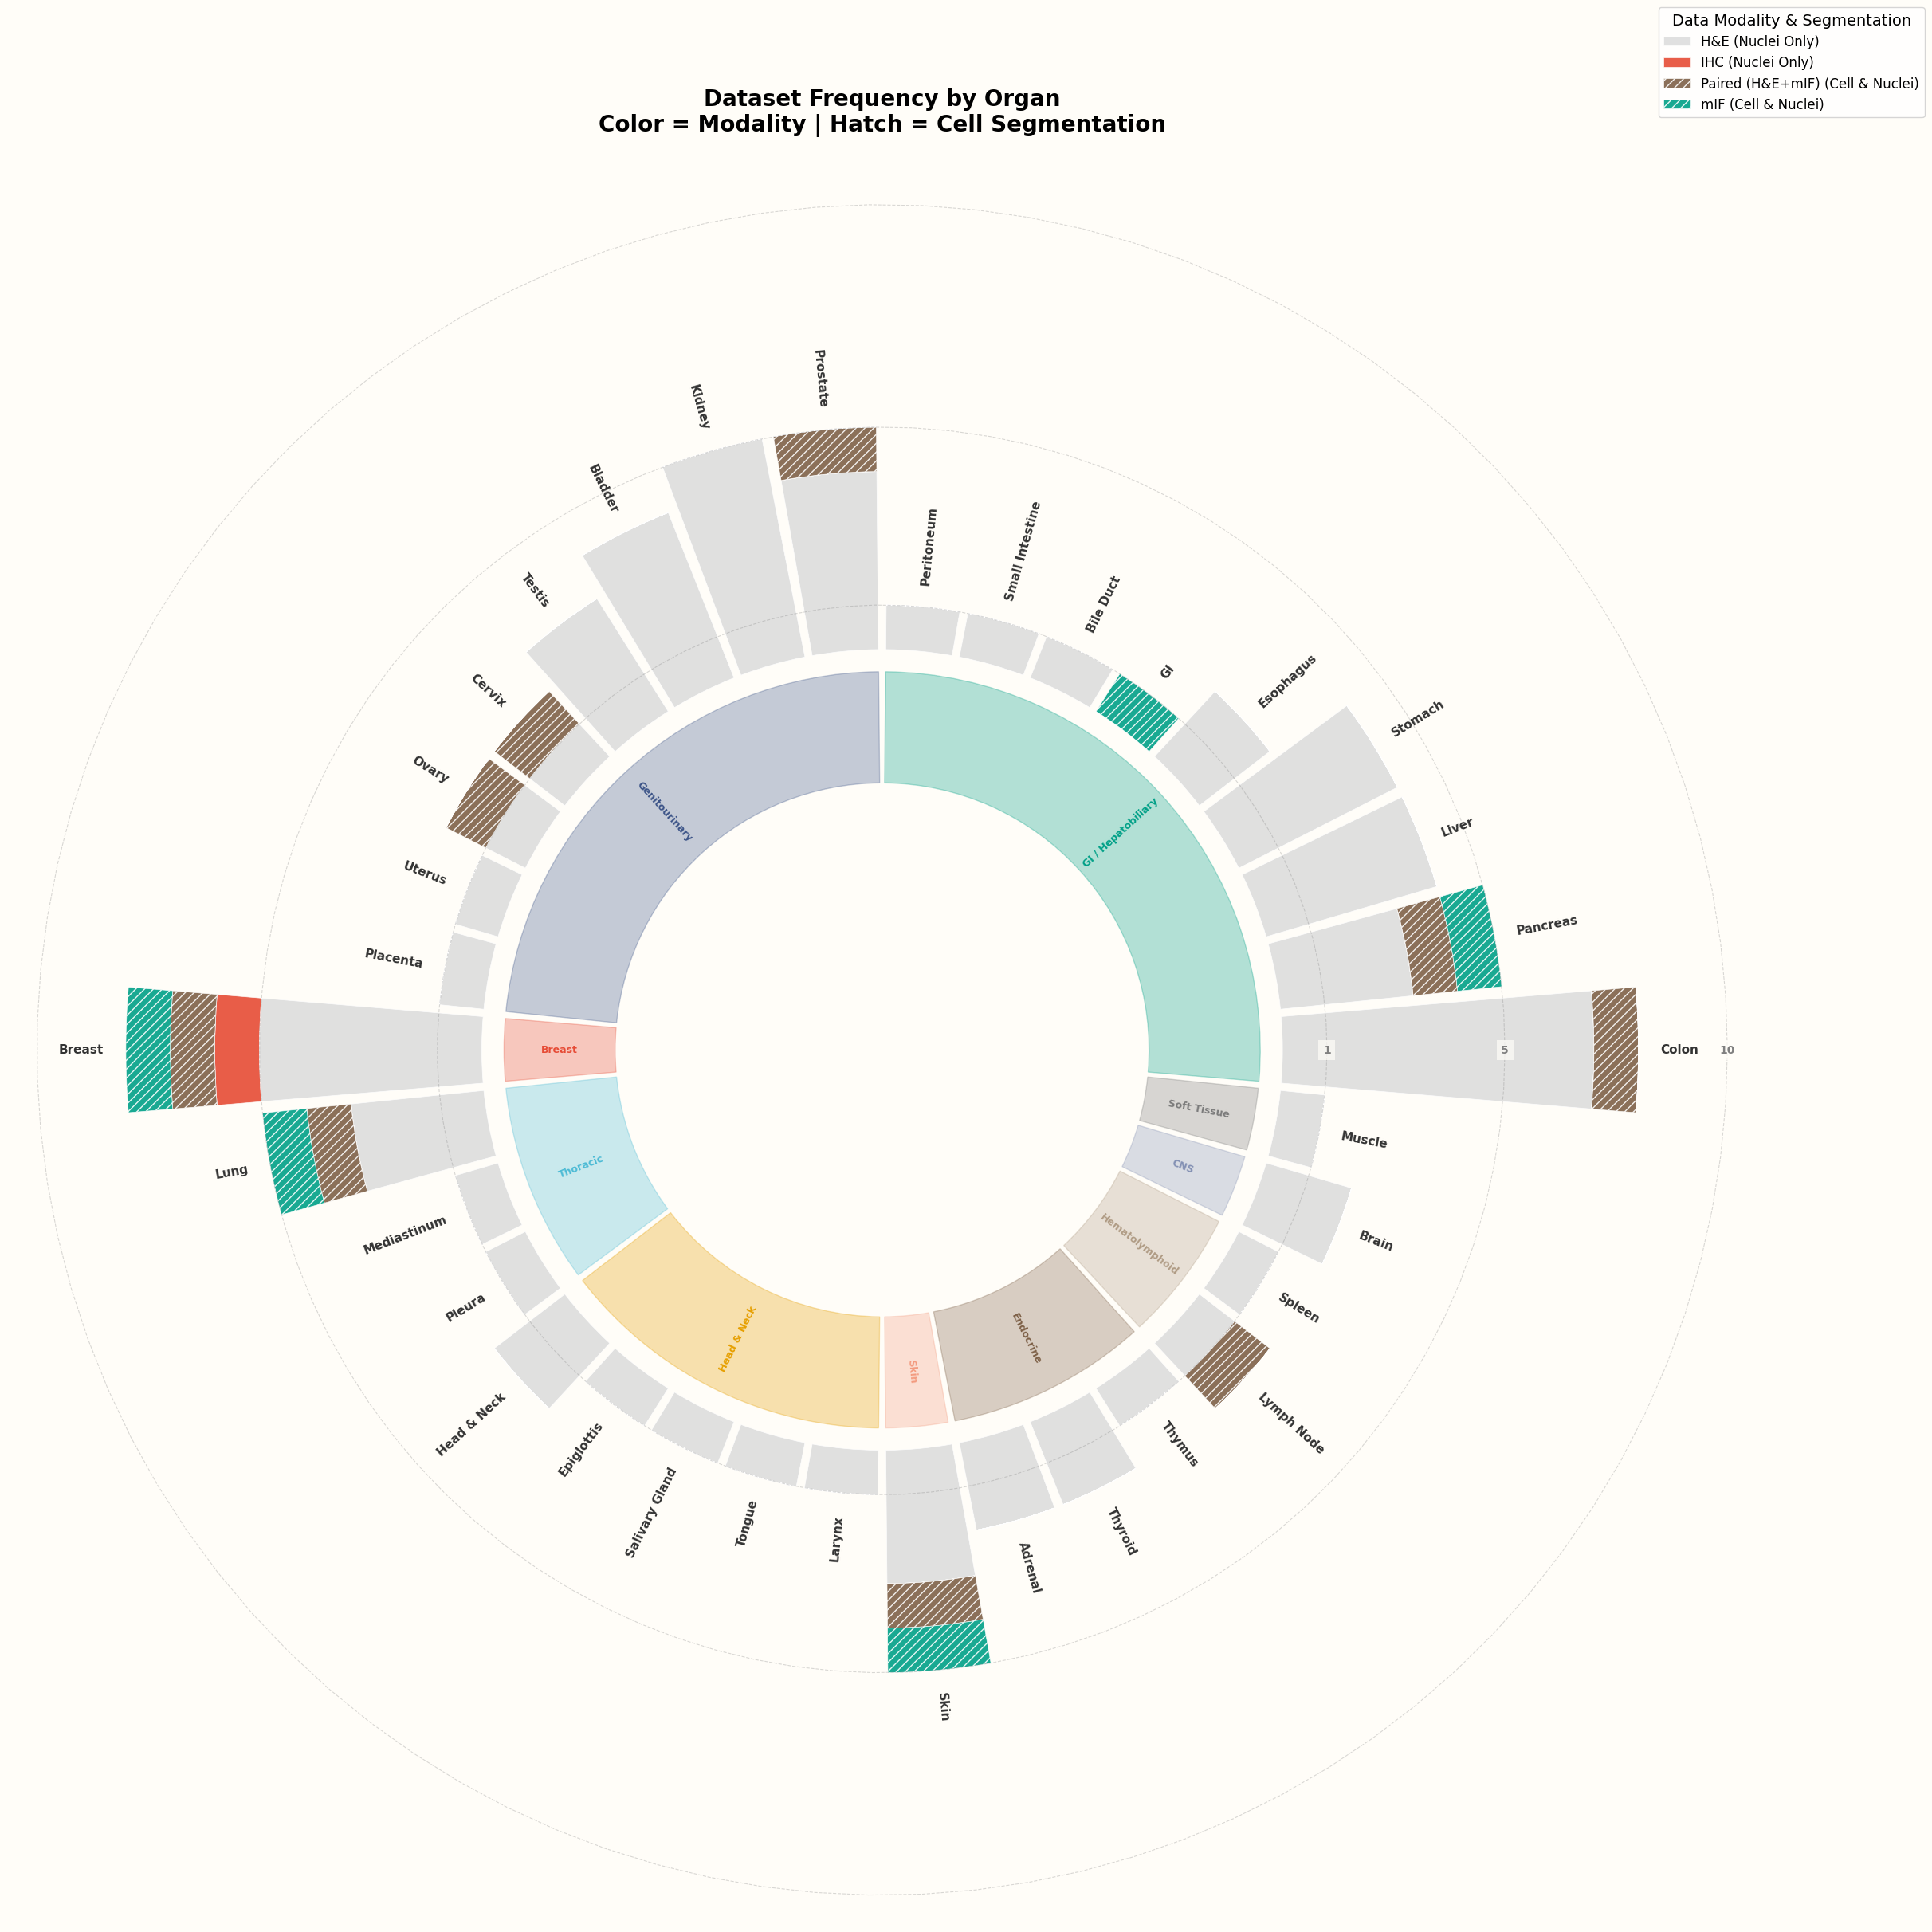

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter

# ==========================================
# 1. DATA PREPARATION
# ==========================================
datasets_organs = {
    'TissueNet': ['Breast', 'GI', 'Lung', 'Pancreas', 'Skin'],
    'Orion CRC': ['Colon'],
    'Xenium': ['Breast', 'Cervix', 'Lung', 'Lymph Node', 'Ovary', 'Pancreas', 'Prostate', 'Skin'],
    'Lizard': ['Colon'],
    'PanNuke': ['Adrenal', 'Bile Duct', 'Bladder', 'Breast', 'Cervix', 'Colon', 'Esophagus', 'Head & Neck', 'Kidney', 'Liver', 'Lung', 'Ovary', 'Pancreas', 'Prostate', 'Skin', 'Stomach', 'Testis', 'Thyroid', 'Uterus'],
    'MoNuSAC': ['Breast', 'Kidney', 'Prostate', 'Colon'],
    'BC': ['Breast'],
    'Kumar': ['Breast', 'Kidney', 'Liver', 'Prostate', 'Bladder', 'Colon', 'Stomach'],
    'NuInsSeg': ['Brain', 'Colon', 'Epiglottis', 'Small Intestine', 'Kidney', 'Liver', 'Lung', 'Skin', 'Muscle', 'Esophagus', 'Pancreas', 'Peritoneum', 'Placenta', 'Salivary Gland', 'Spleen', 'Stomach', 'Testis', 'Tongue', 'Bladder'],
    'MoNuSeg': ['Breast', 'Kidney', 'Liver', 'Prostate', 'Bladder', 'Colon', 'Stomach'],
    'CoNSeP': ['Colon'],
    'CPM-17': ['Brain', 'Head & Neck', 'Lung'],
    'CryoNuSeg': ['Adrenal', 'Larynx', 'Lymph Node', 'Mediastinum', 'Pancreas', 'Pleura', 'Skin', 'Testis', 'Thymus', 'Thyroid'],
    'TNBC': ['Breast']
}

system_map = {
    'Colon': 'GI / Hepatobiliary', 'Stomach': 'GI / Hepatobiliary', 
    'Esophagus': 'GI / Hepatobiliary', 'Small Intestine': 'GI / Hepatobiliary', 'GI': 'GI / Hepatobiliary',
    'Bile Duct': 'GI / Hepatobiliary', 'Liver': 'GI / Hepatobiliary', 
    'Pancreas': 'GI / Hepatobiliary', 'Peritoneum': 'GI / Hepatobiliary',
    'Kidney': 'Genitourinary', 'Bladder': 'Genitourinary', 'Prostate': 'Genitourinary',
    'Testis': 'Genitourinary', 'Ovary': 'Genitourinary', 'Cervix': 'Genitourinary', 
    'Uterus': 'Genitourinary', 'Placenta': 'Genitourinary',
    'Breast': 'Breast',
    'Lung': 'Thoracic', 'Pleura': 'Thoracic', 'Mediastinum': 'Thoracic',
    'Skin': 'Skin',
    'Brain': 'CNS',
    'Head & Neck': 'Head & Neck', 'Larynx': 'Head & Neck', 'Tongue': 'Head & Neck', 
    'Epiglottis': 'Head & Neck', 'Salivary Gland': 'Head & Neck',
    'Thyroid': 'Endocrine', 'Adrenal': 'Endocrine', 'Thymus': 'Endocrine',
    'Lymph Node': 'Hematolymphoid', 'Spleen': 'Hematolymphoid',
    'Muscle': 'Soft Tissue'
}

# --- NEW: Define Dataset Meta-Info (Modality & Seg) ---
# Rules: 
# TissueNet = mIF (Cell+Nuc)
# Orion/Xenium = Paired (Cell+Nuc)
# BC = IHC (Nuc)
# Rest = H&E (Nuc)

dataset_meta = {
    'TissueNet': {'type': 'mIF',           'seg': 'Cell & Nuclei', 'color': '#00A087', 'hatch': '///'}, # Teal
    'Orion CRC': {'type': 'Paired (H&E+mIF)', 'seg': 'Cell & Nuclei', 'color': '#7E6148', 'hatch': '///'}, # Brownish
    'Xenium':    {'type': 'Paired (H&E+mIF)', 'seg': 'Cell & Nuclei', 'color': '#7E6148', 'hatch': '///'},
    'BC':        {'type': 'IHC',           'seg': 'Nuclei Only',   'color': '#E64B35', 'hatch': ''},    # Red
    # Default for all others
    'default':   {'type': 'H&E',           'seg': 'Nuclei Only',   'color': '#DDDDDD', 'hatch': ''}     # Light Grey
}

# 1. Aggregate Data including Modality Info
# Structure: grouped_data[System] = { OrganName: { 'H&E': count, 'mIF': count, ... } }
organ_composition = defaultdict(lambda: defaultdict(int))
organ_total_counts = Counter()

for ds_name, organs in datasets_organs.items():
    meta = dataset_meta.get(ds_name, dataset_meta['default'])
    key = (meta['type'], meta['seg'], meta['color'], meta['hatch'])
    
    for organ in organs:
        organ_composition[organ][key] += 1
        organ_total_counts[organ] += 1

# 2. Group for Plotting (Preserve existing system logic)
system_groups = defaultdict(list)
for organ, total_count in organ_total_counts.items():
    sys = system_map.get(organ, 'Other')
    system_groups[sys].append(organ)

# 3. Sort Systems and Organs
sorted_systems = sorted(system_groups.items(), key=lambda x: sum(organ_total_counts[o] for o in x[1]), reverse=True)

# Flatten for plotting
labels = []
stack_data = defaultdict(list) # {'(Type, Seg)': [val, val, val...]}
stack_keys = [] # To keep order of stacks (e.g. H&E bottom, Paired top)

# Identify all unique stack keys present in data
unique_keys = set()
for org_data in organ_composition.values():
    unique_keys.update(org_data.keys())
# Sort keys to ensure consistent stacking order (put H&E/Simple first, Complex last)
# Sorting by Hatch len (empty first) then Type name ensures H&E (No hatch) is at bottom
sorted_stack_keys = sorted(list(unique_keys), key=lambda x: (len(x[3]), x[0]))

system_boundaries = []
current_idx = 0

# Colors for the Inner Ring (System ID)
system_colors = {
    'GI / Hepatobiliary': '#00A087', 'Genitourinary': '#3C5488', 'Breast': '#E64B35', 
    'Thoracic': '#4DBBD5', 'Skin': '#F39B7F', 'CNS': '#8491B4', 
    'Head & Neck': '#E69F00', 'Endocrine': '#7E6148', 'Hematolymphoid': '#B09C85', 'Soft Tissue': '#7B7B7B'
}

for sys_name, organs in sorted_systems:
    # Sort organs within system by total count
    organs.sort(key=lambda x: organ_total_counts[x], reverse=True)
    
    start_idx = current_idx
    for organ in organs:
        labels.append(organ)
        
        # Populate stack data for this organ position
        comp = organ_composition[organ]
        for key in sorted_stack_keys:
            stack_data[key].append(comp.get(key, 0))
            
        current_idx += 1
    
    system_boundaries.append((start_idx, current_idx, sys_name, system_colors.get(sys_name, '#999')))

# ==========================================
# 2. PLOTTING
# ==========================================
N = len(labels)
theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)
width = (2 * np.pi) / N * 0.9 
bottom_base = 9  

fig, ax = plt.subplots(figsize=(24, 24), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#FFFDF8')
fig.patch.set_facecolor('#FFFDF8')

# 1. Draw Stacked Bars
current_bottom = np.array([bottom_base] * N, dtype=float)

# Loop through our stack layers (Modality types)
for key in sorted_stack_keys:
    d_type, d_seg, d_color, d_hatch = key
    counts = np.array(stack_data[key])
    
    # Only plot if there is data in this layer
    if np.sum(counts) > 0:
        bars = ax.bar(theta, counts, width=width, bottom=current_bottom, 
                      color=d_color, edgecolor='white', linewidth=0.5, 
                      hatch=d_hatch, alpha=0.9, label=f"{d_type} ({d_seg})")
        current_bottom += counts

# 2. Add Reference Circles
yticks = [1, 5, 10]
for y in yticks:
    ax.plot(np.linspace(0, 2*np.pi, 100), [y+bottom_base]*100, color='gray', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.text(0, y+bottom_base, f"{y}", color='gray', fontsize=10, fontweight='bold', ha='center', va='center',  bbox=dict(facecolor='#FFFDF8', edgecolor='none', alpha=0.7))

# 3. Add Labels (Organs)
for angle, label, total_h in zip(theta, labels, current_bottom):
    rotation = np.rad2deg(angle)
    alignment = "left"
    if 90 < rotation < 270:
        rotation += 180
        alignment = "right"
    
    # Position label at the top of the total stack
    ax.text(angle, total_h + 0.5, label, 
            rotation=rotation, ha=alignment, va='center', rotation_mode='anchor',
            fontsize=11, fontweight='bold', color='#333')

# 4. Draw Inner System Rings
for start, end, name, color in system_boundaries:
    start_angle = theta[start] - width/2
    # Fix wrap around index issue
    end_idx = end - 1 if end <= N else 0
    end_angle = theta[end_idx] + width/2
    
    mid_angle = (start_angle + end_angle) / 2
    if start_angle > end_angle: mid_angle += np.pi
    
    ring_height = 2.5
    ring_gap = 0.5
    ring_bottom = bottom_base - ring_height - ring_gap 
    
    # Calculate span correctly handling wrap around
    span = end_angle - start_angle
    if span < 0: span += 2*np.pi
        
    ax.bar(mid_angle, ring_height, width=span, bottom=ring_bottom, 
           color=color, alpha=0.3, edgecolor=color)
    
    label_radius = ring_bottom + (ring_height / 2)
    sys_rot = np.rad2deg(mid_angle)
    if 90 < sys_rot < 270: sys_rot += 180
        
    ax.text(mid_angle, label_radius, name, ha='center', va='center', 
            fontsize=9, fontweight='bold', color=color, rotation=sys_rot, rotation_mode='anchor')

# 5. Custom Legend for Modalities
handles, lbls = ax.get_legend_handles_labels()
# Filter legend to avoid duplicates if any (though stack logic prevents strict dupes)
by_label = dict(zip(lbls, handles))
# Position legend outside
ax.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.1, 1.1), 
          title="Data Modality & Segmentation", fontsize=12, title_fontsize=14)

ax.set_axis_off()
plt.title("Dataset Frequency by Organ\nColor = Modality | Hatch = Cell Segmentation", fontsize=20, fontweight='bold', pad=40)
plt.tight_layout()
plt.show()

Loaded as Excel
Unique datasets after cleaning: 40
Saved: dataset_landscape_matrix.pdf


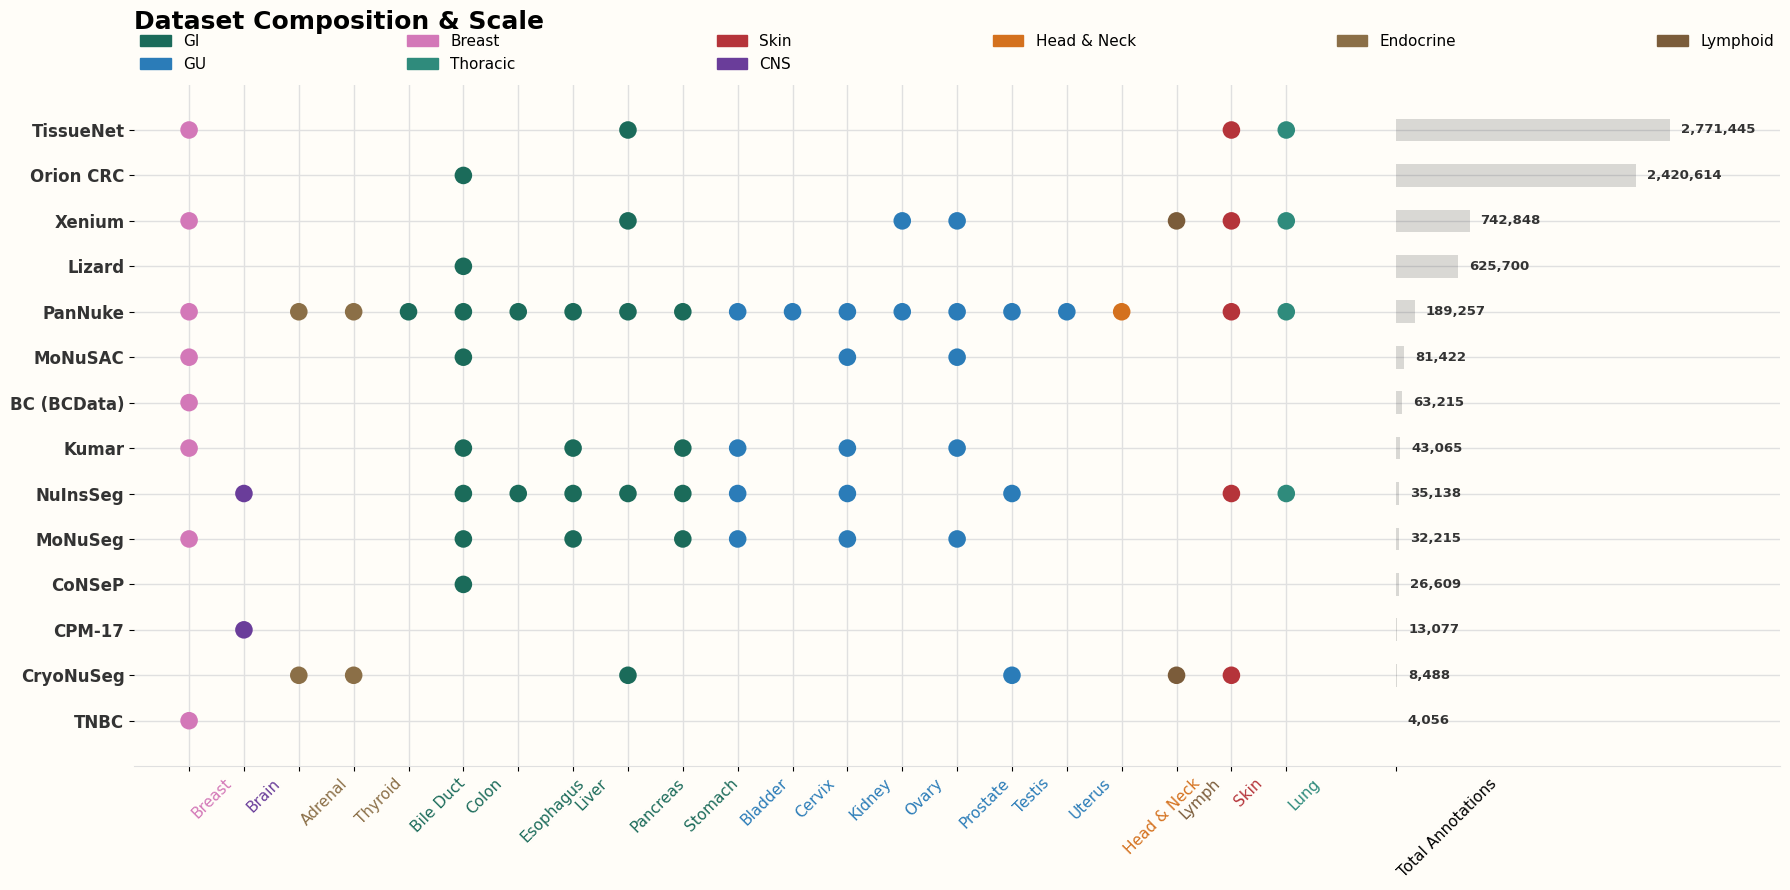

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ==========================================
# 1. LOAD & CLEAN DATA
# ==========================================
file_path = "dataset/Histopathology_Datasets_Summary.xlsx"

# Robust file loading (Excel or CSV fallback)
try:
    df = pd.read_excel(file_path)
    print("Loaded as Excel")
except:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
        print("Loaded as CSV (UTF-8)")
    except:
        df = pd.read_csv(file_path, encoding='ISO-8859-1')
        print("Loaded as CSV (ISO-8859-1)")

# Standardize Column Names
cols = {c.lower(): c for c in df.columns}
dataset_col = cols.get('dataset', 'Dataset')
organ_col   = cols.get('tissue/organ', 'Tissue/Organ')
count_col   = cols.get('total_annotations', 'Total_Annotations')

# --- CRITICAL FIX: Deduplicate Datasets ---
# 1. Drop rows where Dataset is missing
df = df.dropna(subset=[dataset_col])
# 2. Keep only the FIRST occurrence of each dataset (removes the "Recommended Use Cases" duplicates)
df = df.drop_duplicates(subset=[dataset_col], keep='first')
print(f"Unique datasets after cleaning: {len(df)}")

# --- Helper: Organ Parsing ---
organ_alias_map = {
    'colorectal': 'Colon', 'colon': 'Colon', 'rectum': 'Colon',
    'stomach': 'Stomach', 'esophagus': 'Esophagus', 'oesophagus': 'Esophagus',
    'liver': 'Liver', 'pancreas': 'Pancreas', 'bile duct': 'Bile Duct',
    'kidney': 'Kidney', 'bladder': 'Bladder', 'prostate': 'Prostate',
    'testis': 'Testis', 'ovary': 'Ovary', 'ovarian': 'Ovary',
    'breast': 'Breast', 'lung': 'Lung', 'skin': 'Skin', 'melanoma': 'Skin',
    'brain': 'Brain', 'gbm': 'Brain', 'head': 'Head & Neck', 'thyroid': 'Thyroid',
    'adrenal': 'Adrenal', 'lymph': 'Lymph', 'uterus': 'Uterus', 'cervix': 'Cervix'
}

system_map = {
    'Colon': 'GI', 'Stomach': 'GI', 'Esophagus': 'GI', 'Liver': 'GI', 
    'Pancreas': 'GI', 'Bile Duct': 'GI',
    'Kidney': 'GU', 'Bladder': 'GU', 'Prostate': 'GU', 'Testis': 'GU', 
    'Ovary': 'GU', 'Uterus': 'GU', 'Cervix': 'GU',
    'Breast': 'Breast', 'Lung': 'Thoracic', 'Skin': 'Skin', 
    'Brain': 'CNS', 'Head & Neck': 'Head & Neck', 
    'Thyroid': 'Endocrine', 'Adrenal': 'Endocrine', 'Lymph': 'Lymphoid'
}

def get_organs(text):
    if not isinstance(text, str) or text in ['Yes', 'No', 'Partial']: return []
    text = text.lower()
    found = set()
    
    # Check for direct mentions
    for key, val in organ_alias_map.items():
        if key in text:
            found.add(val)
    
    # Special handling for "19 tissues" lists
    if '(' in text:
        try:
            content = text.split('(')[1].split(')')[0]
            for item in content.split(','):
                item = item.strip()
                for key, val in organ_alias_map.items():
                    if key in item:
                        found.add(val)
        except:
            pass
    return list(found)

# Build the Matrix Data
matrix_data = []
for idx, row in df.iterrows():
    d_name = str(row[dataset_col]).strip()
    if d_name.lower() in ['nan', '', 'recommended use cases']: continue
    
    # Get annotations count (clean non-numeric)
    try:
        raw_count = str(row[count_col])
        # Extract numbers, ignore "approx" etc.
        digits = re.sub(r'[^\d]', '', raw_count)
        count = int(digits) if digits else 0
    except:
        count = 0

    organs = get_organs(row[organ_col])
    
    # Create a record
    if organs: # Only add if we found organs or it's a known dataset
        record = {'Dataset': d_name, 'Count': count}
        for org in organs:
            record[org] = 1
        matrix_data.append(record)

df_mat = pd.DataFrame(matrix_data).fillna(0)
df_mat = df_mat.set_index('Dataset')

# Sort columns by System
all_organs = [c for c in df_mat.columns if c != 'Count']
all_organs_sorted = sorted(all_organs, key=lambda x: (system_map.get(x, 'Z'), x))

# Sort rows by Total Count (for better visual hierarchy)
df_mat = df_mat.sort_values('Count', ascending=True) 

# ==========================================
# 2. PLOTTING
# ==========================================
# Dynamic height based on number of datasets
fig, ax = plt.subplots(figsize=(18, len(df_mat) * 0.5 + 2))
ax.set_facecolor('#FFFDF8')
fig.patch.set_facecolor('#FFFDF8')

# Grid
y_positions = range(len(df_mat))
x_positions = range(len(all_organs_sorted))

for y in y_positions:
    ax.axhline(y, color='#E0E0E0', linewidth=1, zorder=1)
for x in x_positions:
    ax.axvline(x, color='#E0E0E0', linewidth=1, zorder=1)

# Colors
sys_colors = {
    'GI': '#1B6B5A', 'GU': '#2B7CB8', 'Breast': '#D378B8', 
    'Thoracic': '#2F8B7C', 'Skin': '#B5343A', 'CNS': '#6A3D9A',
    'Head & Neck': '#D4711E', 'Endocrine': '#8B6F47', 'Lymphoid': '#7B5C3A'
}

# Plot Dots
for i, dataset in enumerate(df_mat.index):
    # Using .at to avoid Series ambiguity
    for j, organ in enumerate(all_organs_sorted):
        if df_mat.at[dataset, organ] == 1:
            sys = system_map.get(organ, 'Other')
            col = sys_colors.get(sys, '#777777')
            ax.scatter(j, i, s=160, color=col, zorder=3, edgecolors='none')

# --- Bar Chart (Number in a Row) ---
max_x = len(all_organs_sorted)
bar_start = max_x + 1
max_count = df_mat['Count'].max()
# Scale bars to fit in roughly 5-6 units of x-axis space
bar_width_scale = 5 / max_count if max_count > 0 else 1

for i, count in enumerate(df_mat['Count']):
    bar_len = count * bar_width_scale
    if bar_len > 0:
        ax.barh(i, bar_len, left=bar_start, height=0.5, color='#444444', alpha=0.2, zorder=2)
    
    # Add number text
    display_num = f"{count:,}" if count > 0 else "N/A"
    ax.text(bar_start + bar_len + 0.2, i, display_num, 
            va='center', ha='left', fontsize=9.5, fontweight='bold', color='#333333')

# Formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(df_mat.index, fontsize=12, fontweight='bold', color='#333333')

ax.set_xticks(list(x_positions) + [bar_start])
# Color-code the x-labels
x_labels = all_organs_sorted + ['Total Annotations']
ax.set_xticklabels(x_labels, rotation=45, ha='left', fontsize=11, fontweight='500')

for tick_label in ax.get_xticklabels():
    txt = tick_label.get_text()
    if txt in all_organs_sorted:
        sys = system_map.get(txt, 'Other')
        tick_label.set_color(sys_colors.get(sys, '#333'))

ax.set_xlim(-1, bar_start + 7)
ax.set_ylim(-1, len(df_mat))

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#E0E0E0')

plt.title("Dataset Composition & Scale", fontsize=18, fontweight='bold', pad=40, loc='left')

# Legend
handles = [mpatches.Patch(color=c, label=s) for s, c in sys_colors.items()]
plt.legend(handles=handles, bbox_to_anchor=(0, 1.01, 1, 0.2), loc="lower left",
           mode="expand", borderaxespad=0, ncol=6, frameon=False, fontsize=11)

plt.tight_layout()
print("Saved: dataset_landscape_matrix.pdf")
plt.show()

Chart saved as organ_distribution_progressbar.png


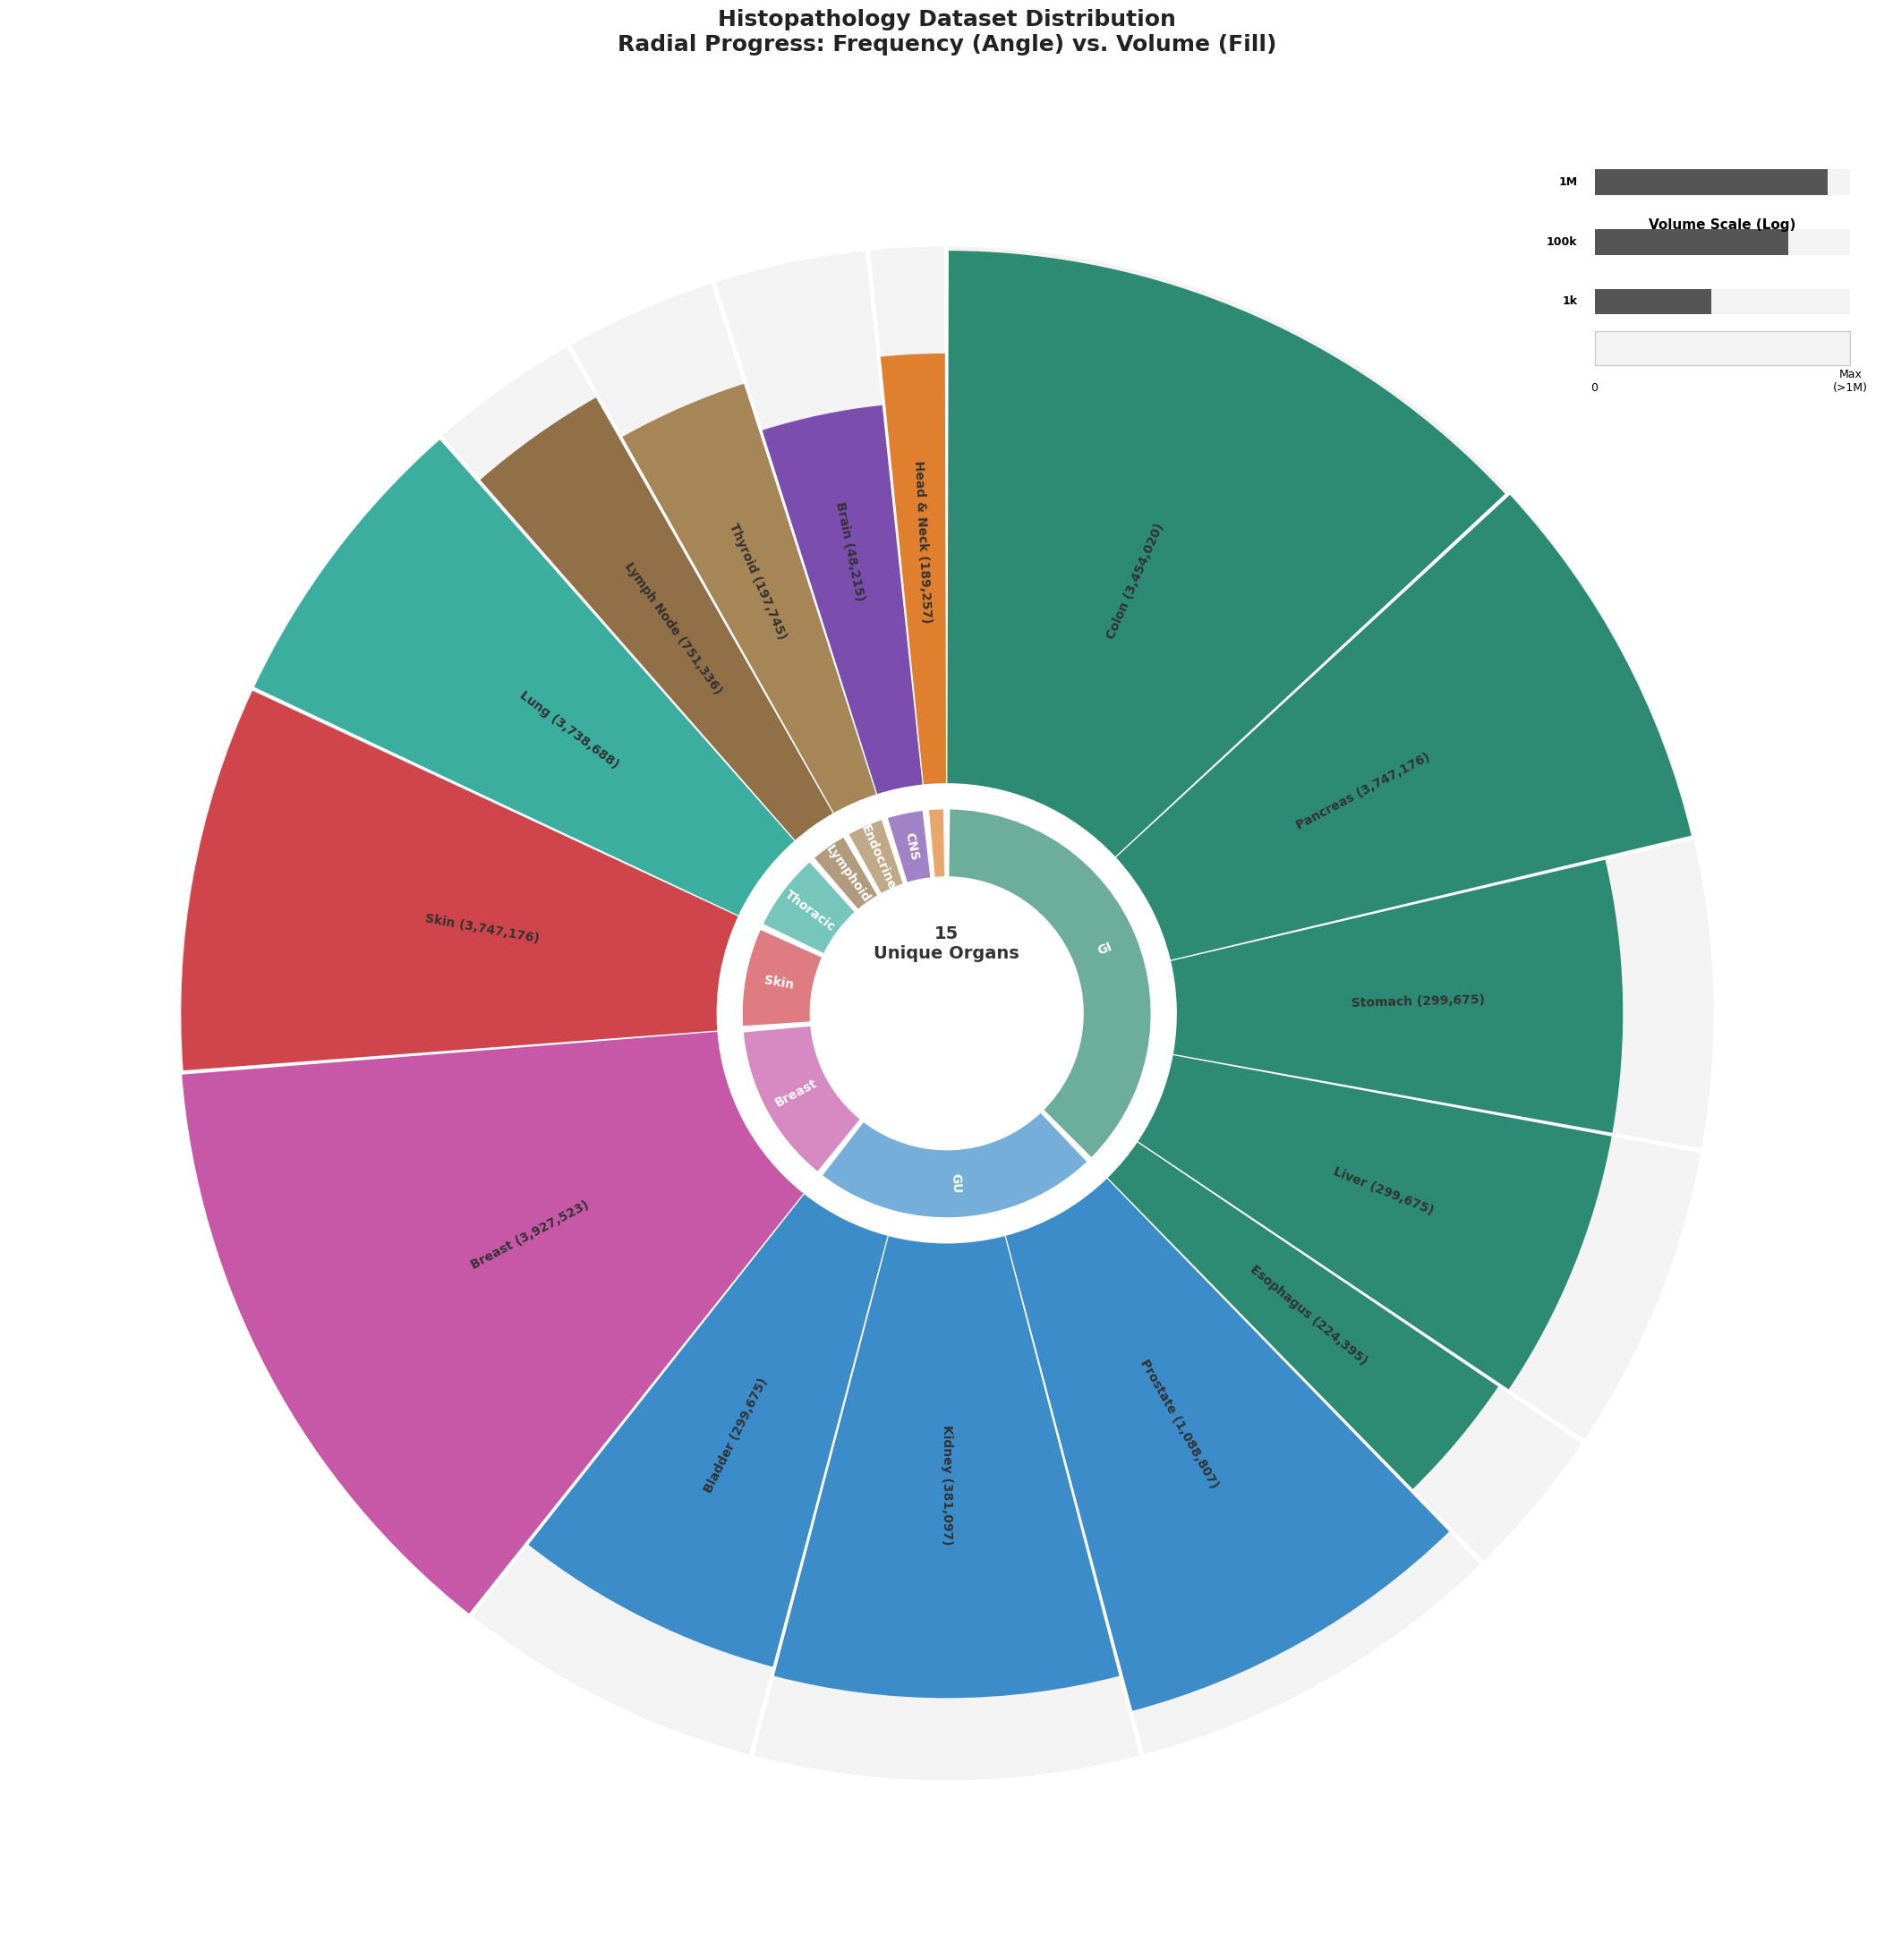

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from matplotlib.patches import Wedge, Rectangle
from collections import defaultdict, Counter
import matplotlib.colors as mcolors

# ==========================================
# 1. DATA LOADING & PREP (Robust)
# ==========================================
file_path = "dataset/Histopathology_Datasets_Summary.xlsx"
df = None

# Robust Loading Sequence
try:
    df = pd.read_excel(file_path)
except:
    try:
        df = pd.read_csv(file_path, encoding='utf-8')
    except:
        try:
            df = pd.read_csv(file_path, encoding='ISO-8859-1')
        except:
            print("Warning: File not found. Using dummy data.")
            # Create dummy data suitable for this visualization style
            categories = ['GI', 'GU', 'Breast', 'Thoracic', 'Skin', 'CNS'] * 3
            organs = ['Colon', 'Liver', 'Pancreas', 'Kidney', 'Prostate', 'Bladder', 
                      'Breast Cancer', 'Lung', 'Melanoma', 'Brain', 'Glioblastoma', 'Head&Neck',
                      'Stomach', 'Esophagus', 'Ovary', 'Cervix', 'Thyroid', 'Lymph Node']
            data = {
                'Dataset': [f'DS_{i}' for i in range(len(organs))],
                'Tissue/Organ': organs,
                # Mix of small and very large numbers to show the progress bar effect
                'Total_Annotations': np.concatenate([np.random.randint(100, 5000, 10), 
                                                     np.random.randint(50000, 1000000, 8)])
            }
            df = pd.DataFrame(data)

# Clean Names
cols = {c.lower(): c for c in df.columns}
organ_col = cols.get('tissue/organ', 'Tissue/Organ')
count_col = cols.get('total_annotations', 'Total_Annotations')
dataset_col = cols.get('dataset', 'Dataset')

if dataset_col in df.columns:
    df = df.dropna(subset=[dataset_col])
    df = df.drop_duplicates(subset=[dataset_col], keep='first')

# Mappings
organ_alias_map = {
    'colorectal': 'Colon', 'colon': 'Colon', 'rectum': 'Colon',
    'stomach': 'Stomach', 'esophagus': 'Esophagus', 'liver': 'Liver', 
    'pancreas': 'Pancreas', 'kidney': 'Kidney', 'bladder': 'Bladder', 
    'prostate': 'Prostate', 'ovary': 'Ovary', 'breast': 'Breast', 
    'lung': 'Lung', 'skin': 'Skin', 'melanoma': 'Skin', 'brain': 'Brain', 
    'gbm': 'Brain', 'head': 'Head & Neck', 'thyroid': 'Thyroid', 
    'lymph': 'Lymph Node'
}

system_map = {
    'Colon': 'GI', 'Stomach': 'GI', 'Esophagus': 'GI', 'Liver': 'GI', 'Pancreas': 'GI',
    'Kidney': 'GU', 'Bladder': 'GU', 'Prostate': 'GU', 'Ovary': 'GU',
    'Breast': 'Breast', 'Lung': 'Thoracic', 'Skin': 'Skin', 
    'Brain': 'CNS', 'Head & Neck': 'Head & Neck', 
    'Thyroid': 'Endocrine', 'Lymph Node': 'Lymphoid'
}

def parse_organs(text):
    if not isinstance(text, str): return []
    text = text.lower()
    found = set()
    for key, val in organ_alias_map.items():
        if key in text: found.add(val)
    return list(found)

def parse_count(val):
    try:
        clean = re.sub(r'[^\d]', '', str(val))
        return int(clean) if clean else 0
    except: return 0

# Aggregation
cat_counts = defaultdict(Counter)
organ_samples = defaultdict(int)

for idx, row in df.iterrows():
    organs = parse_organs(row.get(organ_col, ''))
    n_samples = parse_count(row.get(count_col, 0))
    for organ in organs:
        cat = system_map.get(organ, 'Other')
        cat_counts[cat][organ] += 1
        organ_samples[organ] += n_samples

sorted_cats = sorted(cat_counts.items(), key=lambda x: -sum(x[1].values()))
total_datasets = sum(sum(v.values()) for v in cat_counts.values())

if total_datasets == 0: exit()

# ==========================================
# 2. RADIUS SCALING (Progress Bar Logic)
# ==========================================
max_samples = max(organ_samples.values()) if organ_samples else 100000

# Define the drawing area radii
inner_r1, inner_r2 = 0.8, 1.2  # Inner system ring
bar_start_r = 1.35             # Where the progress bars start
max_radius = 4.5               # The fixed outer limit of the "tracks"

# Scale data to fit between bar_start_r and max_radius
def get_filled_radius(n_samples):
    if n_samples <= 0: return bar_start_r
    # Log normalization (base 10)
    # Avoid log(0) by using at least 1 sample
    val = max(1, n_samples)
    norm = np.log10(val) / np.log10(max_samples)
    norm = max(0, min(1, norm)) # Clip 0-1
    
    # map 0-1 to the available bar space
    return bar_start_r + norm * (max_radius - bar_start_r)

# ==========================================
# 3. PLOTTING
# ==========================================
# Using slightly darker outer colors for better contrast against the light track
colors_outer = {
    'GI': '#2E8B73', 'GU': '#3B8CC9', 'Breast': '#C758A8', 
    'Thoracic': '#3CAEA0', 'Skin': '#D0454C', 'CNS': '#7A4DAF',
    'Head & Neck': '#E0802E', 'Endocrine': '#A68557', 'Lymphoid': '#917048', 'Other': '#999'
}

fig, ax = plt.subplots(figsize=(22, 22))
ax.set_aspect('equal')
ax.axis('off')
# A clean white background fits this modern style better
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)

current_angle = 90
cat_gap = 1.5
default_type_gap = 0.3

for cat, type_counter in sorted_cats:
    cat_total = sum(type_counter.values())
    cat_span = (cat_total / total_datasets) * 360
    cat_start, cat_end = current_angle, current_angle - cat_span
    
    # -- 1. Inner Ring (System Category) --
    mid_ang = (cat_start + cat_end) / 2
    if cat_start > cat_end:
        # Use a slightly desaturated version of the outer color for the inner ring
        inner_col = mcolors.to_rgba(colors_outer.get(cat, '#999'), alpha=0.7)
        ax.add_patch(Wedge((0,0), inner_r2, cat_end + cat_gap/2, cat_start - cat_gap/2, 
                           width=inner_r2-inner_r1, facecolor=inner_col, edgecolor='white', lw=1))
    
    if cat_span > 6:
        rad, lbl_r = np.deg2rad(mid_ang), (inner_r1 + inner_r2)/2
        rot = mid_ang - 180 if 90 < mid_ang % 360 < 270 else mid_ang
        ax.text(lbl_r*np.cos(rad), lbl_r*np.sin(rad), cat, ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10, rotation=rot, rotation_mode='anchor')

    # -- 2. Outer Progress Bars (Organs) --
    cur = cat_start
    for organ, count in type_counter.most_common():
        span = (count / total_datasets) * 360
        samples = organ_samples.get(organ, 0)
        
        # Calculate actual filled radius
        r_filled = get_filled_radius(samples)
        
        actual_gap = default_type_gap if span > default_type_gap * 3 else 0
        w_start, w_end = cur - actual_gap/2, (cur - span) + actual_gap/2
        
        if w_start > w_end:
            # A. Draw Background "Track" (Empty State)
            # Fixed radius from bar_start_r to max_radius. Light gray color.
            ax.add_patch(Wedge((0,0), max_radius, w_end, w_start, 
                               width=max_radius - bar_start_r,
                               facecolor='#F3F3F3', edgecolor='white', lw=0.5, zorder=1))

            # B. Draw Foreground "Fill" (Full State)
            # Variable radius based on data. Category color.
            if r_filled > bar_start_r + 0.01: # Only draw if there's data
                ax.add_patch(Wedge((0,0), r_filled, w_end, w_start,
                                   width=r_filled - bar_start_r,
                                   facecolor=colors_outer.get(cat, '#AAA'), edgecolor='none', alpha=1.0, zorder=2))
            
            # C. Label Inside the Bar
            mid_w = (w_start + w_end)/2
            mid_rad = np.deg2rad(mid_w)
            
            # Place label roughly in the middle of the fixed track
            lbl_r = bar_start_r + (max_radius - bar_start_r) * 0.45
            lbl_x, lbl_y = lbl_r * np.cos(mid_rad), lbl_r * np.sin(mid_rad)
            
            rot = mid_w - 180 if 90 < mid_w % 360 < 270 else mid_w
            
            # Label text color (dark gray for contrast on both fill and empty bg)
            txt_col = '#333333'
            
            # Determine font size based on span available
            fs = 10 if span > 3 else (8 if span > 1.5 else 0)
            if fs > 0:
                # Add sample count to label for extra detail
                label_text = f"{organ} ({samples:,})" if span > 5 else organ
                ax.text(lbl_x, lbl_y, label_text, ha='center', va='center', 
                        fontsize=fs, fontweight='600', rotation=rot, rotation_mode='anchor', color=txt_col, zorder=3)
        
        cur -= span
    current_angle -= cat_span

# ==========================================
# 4. UPDATED LEGEND (Progress Bar Style)
# ==========================================
scale_x, scale_y = 0, 0 # Center marks
ax.text(scale_x, scale_y + 0.3, f"{len(organ_samples)}\nUnique Organs", 
        ha='center', va='bottom', fontsize=14, fontweight='bold', color='#333')

#--- New Legend Block ---
leg_x, leg_y = 3.8, 3.8
ax.text(leg_x + 0.75, leg_y + 0.8, "Volume Scale (Log)", ha='center', fontsize=11, fontweight='bold')

# Draw visualization of the progress bar concept
# Background track for legend
rect_bg = Rectangle((leg_x, leg_y), 1.5, 0.2, facecolor='#F3F3F3', edgecolor='#CCC')
ax.add_patch(rect_bg)
ax.text(leg_x, leg_y - 0.15, "0", ha='center', fontsize=9)
ax.text(leg_x + 1.5, leg_y - 0.15, "Max\n(>1M)", ha='center', fontsize=9)

# Example fills
ex_vals = [1000, 100000, 1000000]
ex_labels = ["1k", "100k", "1M"]
bar_y_start = leg_y + 0.3

for i, (val, label) in enumerate(zip(ex_vals, ex_labels)):
    y_pos = bar_y_start + i*0.35
    # Calculate proportional width for legend based on log scale
    norm_len = np.log10(val) / np.log10(max_samples) if max_samples > 0 else 0
    norm_len = max(0.05, min(1.5, norm_len * 1.5)) # Scale to legend width
    
    # Background
    ax.add_patch(Rectangle((leg_x, y_pos), 1.5, 0.15, facecolor='#F3F3F3', edgecolor='none'))
    # Foreground fill
    ax.add_patch(Rectangle((leg_x, y_pos), norm_len, 0.15, facecolor='#555', edgecolor='none'))
    # Label
    ax.text(leg_x - 0.1, y_pos + 0.075, label, ha='right', va='center', fontsize=9, fontweight='bold')

plt.title("Histopathology Dataset Distribution\nRadial Progress: Frequency (Angle) vs. Volume (Fill)", 
          fontsize=18, pad=20, fontweight='bold', color='#222')

plt.tight_layout()
print("Chart saved as organ_distribution_progressbar.png")
plt.show()

In [2]:
import plotly.graph_objects as go

# Data: Modality -> Organ -> Count (number of datasets)
data = {
    'H&E': {
        'Breast': 4, 'Colon': 5, 'Kidney': 4, 'Prostate': 4, 'Bladder': 3,
        'Liver': 3, 'Stomach': 3, 'Head & Neck': 2, 'Adrenal': 1, 'Bile Duct': 1,
        'Brain': 1, 'Cervix': 1, 'Esophagus': 1, 'Lung': 1, 'Ovarian': 1,
        'Pancreas': 1, 'Skin': 1, 'Testis': 1, 'Thyroid': 1, 'Uterus': 1
    },
    'H&E (Frozen)': {
        'Adrenal': 1, 'Larynx': 1, 'Lymph Node': 1, 'Mediastinum': 1,
        'Pancreas': 1, 'Pleura': 1, 'Skin': 1, 'Testis': 1, 'Thymus': 1, 'Thyroid': 1
    },
    'H&E + MIF': {'Colon': 1},
    'MIF': {'Breast': 1, 'Gastrointestinal': 1, 'Lung': 1, 'Pancreas': 1, 'Skin': 1},
    'Spatial Transcriptomics': {
        'Breast': 1, 'Cervix': 1, 'Lung': 1, 'Lymph Node': 1,
        'Ovarian': 1, 'Pancreas': 1, 'Prostate': 1, 'Skin': 1
    }
}

labels = ['All Datasets']
parents = ['']
values = [0]
colors = []

modality_colors = {
    'H&E': '#FF6B6B',
    'H&E (Frozen)': '#FFA07A',
    'H&E + MIF': '#FFD93D',
    'MIF': '#6BCB77',
    'Spatial Transcriptomics': '#4D96FF'
}

for modality in data.keys():
    total = sum(data[modality].values())
    labels.append(modality)
    parents.append('All Datasets')
    values.append(total)
    colors.append(modality_colors[modality])

for modality, organs in data.items():
    for organ, count in organs.items():
        labels.append(organ)
        parents.append(modality)
        values.append(count)
        colors.append(modality_colors[modality])

fig = go.Figure(go.Sunburst(
    labels=labels, parents=parents, values=values,
    marker=dict(colors=colors),
    hovertemplate='<b>%{label}</b><br>Datasets: %{value}<extra></extra>',
    textfont=dict(size=10, color='white')
))

fig.update_layout(
    title='Histopathology Dataset Coverage: Modality × Organ',
    height=900, width=1000
)

fig.show()

In [4]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.16.0-py3-none-any.whl.metadata (14 kB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.16.0-py3-none-any.whl (443 kB)

[notice] A new release of pip is available: 23.3.1 -> 26.0
[notice] To update, run: pip install --upgrade pip
